<a href="https://colab.research.google.com/github/shonnvs-code/Team4-A1-BA820-Project/blob/main/M4_FILES/Akhil_Nair_Project_M4_Q3_BA820_A1_Team_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.1 Executive Summary**

This study investigates whether the cost gradients for infants and preschools and the price disparities between centers and family providers in childcare across U.S. counties are more closely correlated with socioeconomic similarity than with geographic proximity. The study first uses exploratory data analysis to uncover price trends, and then it uses K-means clustering to identify unique pricing structure regimes using county-level childcare cost data together with labor force, income, and poverty factors.

Higher-income counties typically show steeper gradients and wider center-family differentials, according to preliminary EDA, which also shows significant variance in age-based pricing gradients and provider price gaps across counties. While geographic grouping by itself is unable to adequately explain observed trends, correlation and distributional analyses show that these pricing structures are consistently linked to median family income, poverty rates, and female labor force participation.

# **2. The Dataset**

2.1 About the Dataset

The two excel files that were used for this exploration contains information from 2008 to 2018 about the different counties that were measured and the associated factors that went into rearing children. This includes but is not limited to:


*   The poverty Rate for individuals
*   Unemployment rate of the population
*   Racial background
*   Number of households with children under 6 years old with two parents that are both working





In [ ]:
# Importing the Dataset and relevant Libraries.

from google.colab import drive
drive.mount("/content/drive")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
!pip -q install umap-learn
import umap

Mounted at /content/drive


In [ ]:
childcare = pd.read_csv("/content/drive/MyDrive/childcare_costs.csv")
counties  = pd.read_csv("/content/drive/MyDrive/counties.csv")

print("childcare shape:", childcare.shape)
print("counties shape:", counties.shape)

df = childcare.merge(counties, on="county_fips_code", how="left")
print("merged shape:", df.shape)

childcare shape: (34567, 61)
counties shape: (3144, 4)
merged shape: (34567, 64)


In [ ]:
df.describe()

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,34567.000000,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,23593.000000,23383.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000
mean,30388.132786,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,...,23.456238,7.634403,101.234253,92.523582,146.051770,130.482768,122.232852,113.421657,106.759749,104.189510
std,15161.015383,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,...,7.956927,4.501044,34.552888,27.669904,53.698566,43.775370,38.538323,32.819372,29.982431,28.961701
min,1001.000000,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,...,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000
25%,18177.000000,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,...,17.610000,4.410000,78.650000,75.000000,108.750000,100.000000,95.880000,90.000000,85.085000,84.255000
50%,29177.000000,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,...,23.400000,6.630000,96.530000,88.180000,134.500000,120.990000,113.990000,106.000000,100.250000,99.650000
75%,45081.000000,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,...,28.930000,9.920000,119.380000,107.500000,166.330000,148.710000,139.300000,129.315000,124.950000,120.200000
max,56045.000000,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,...,87.500000,66.480000,375.400000,308.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


# **3. Preliminary EDA**

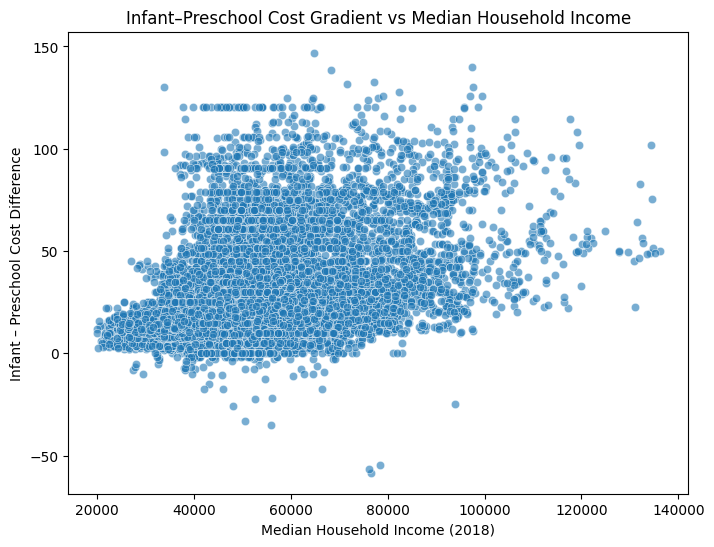

In [ ]:
#Infant–Preschool Cost Gradient vs Median Household Income
df["infant_preschool_gradient"] = df["mc_infant"] - df["mc_preschool"]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="mhi_2018",
    y="infant_preschool_gradient",
    alpha=0.6
)
plt.title("Infant–Preschool Cost Gradient vs Median Household Income")
plt.xlabel("Median Household Income (2018)")
plt.ylabel("Infant – Preschool Cost Difference")
plt.show()

The steepness of the age-based pricing gradient between counties is depicted in this graph. In comparison to preschool care, baby care has a higher price premium, as indicated by a wider gradient. It indicates that pricing structures react to socioeconomic capabilities rather than just local prices if higher-income counties continuously display steeper gradients. Testing whether pricing similarity correlates with income similarity rather than geographic proximity is directly supported by this.

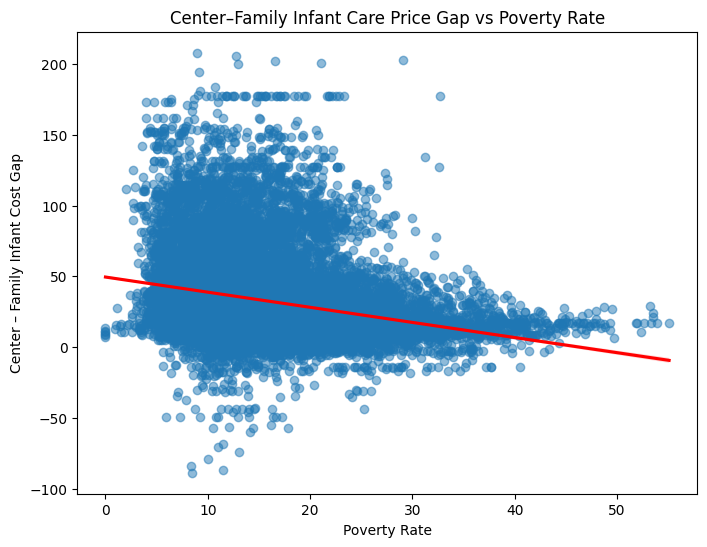

In [ ]:
#Center–Family Infant Care Price Gap vs Poverty Rate
df["provider_price_gap"] = df["mc_infant"] - df["mfcc_infant"]

plt.figure(figsize=(8,6))
sns.regplot(
    data=df,
    x="pr_p",
    y="provider_price_gap",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
plt.title("Center–Family Infant Care Price Gap vs Poverty Rate")
plt.xlabel("Poverty Rate")
plt.ylabel("Center – Family Infant Cost Gap")
plt.show()

The division of providers, not total pricing levels, is the main emphasis of this image. Constrained pricing power for center-based suppliers would be indicated by a shrinking gap at greater poverty rates. A growing disparity in low-poverty counties points to ability-to-pay-based market stratification. This aids in determining whether variations in provider prices are due to socioeconomic structure rather than geography.

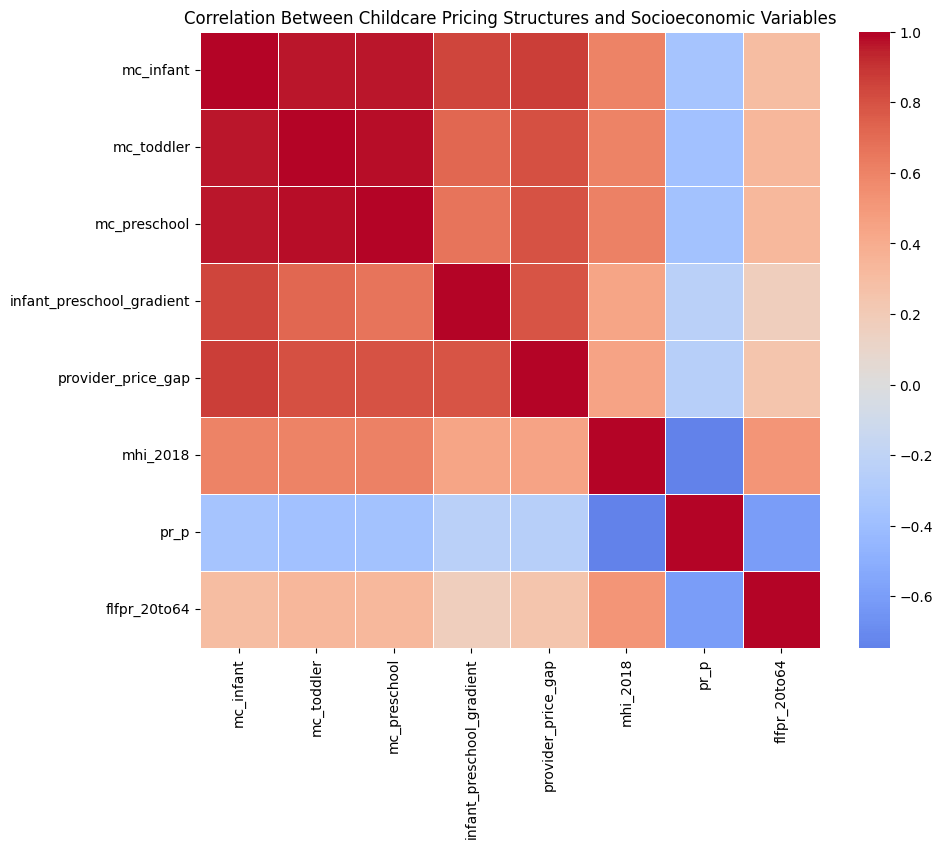

In [ ]:
#Correlation Between Childcare Pricing Structures and Socioeconomic Variables
pricing_vars = [
    "mc_infant",
    "mc_toddler",
    "mc_preschool",
    "infant_preschool_gradient",
    "provider_price_gap"
]

socio_vars = [
    "mhi_2018",
    "pr_p",
    "flfpr_20to64"
]

corr_df = df[pricing_vars + socio_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Between Childcare Pricing Structures and Socioeconomic Variables")
plt.show()


This heatmap illustrates whether socioeconomic characteristics and pricing features change together. Systematic alignment is shown by strong relationships with wealth, poverty, or female labor force participation. Fragmented or locally unique pricing would be implied by weak relationships between pricing variables. This offers preliminary proof that socioeconomic similarity is a more potent organizing principle.

# **3. Pricing Structure Feature Engineering**

In [ ]:
required_cols = [
    "county_fips_code",
    "mc_infant","mc_toddler","mc_preschool",
    "mfcc_infant","mfcc_toddler","mfcc_preschool",
    "mhi_2018","pr_p","flfpr_20to64"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

df_work = df.copy()

# Pricing structure features
df_work["infant_preschool_gradient_center"] = df_work["mc_infant"] - df_work["mc_preschool"]
df_work["toddler_preschool_gradient_center"] = df_work["mc_toddler"] - df_work["mc_preschool"]

df_work["provider_gap_infant_center_minus_family"] = df_work["mc_infant"] - df_work["mfcc_infant"]
df_work["provider_gap_preschool_center_minus_family"] = df_work["mc_preschool"] - df_work["mfcc_preschool"]

cluster_features = [
    "infant_preschool_gradient_center",
    "toddler_preschool_gradient_center",
    "provider_gap_infant_center_minus_family",
    "provider_gap_preschool_center_minus_family"
]

df_model = df_work[["county_fips_code"] + cluster_features + socio_vars].dropna().copy()
print("df_model shape:", df_model.shape)

df_model shape: (23342, 8)


In [ ]:
X = df_model[cluster_features].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

# **4. PCA- Finding the structure linearity**

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print("PCA variance explained:", np.round(explained, 4))
print("Cumulative:", np.round(explained.sum(), 4))

PCA variance explained: [0.6458 0.2253]
Cumulative: 0.8711


The PCA results indicate that the first principal component explains approximately 64.6% of the total variation in pricing structure features, while the second component explains an additional 22.5%. Together, the first two components account for 87.1% of the overall variance. This concentration of variance in a small number of components suggests that most structural differences across counties lie along a dominant underlying dimension rather than across multiple independent regimes. In practical terms, the pricing gradients and provider gaps appear to move together, reflecting a strong, continuous affordability spectrum. This supports the idea that childcare markets may be organized more along a single structural gradient than as sharply separated pricing regimes.


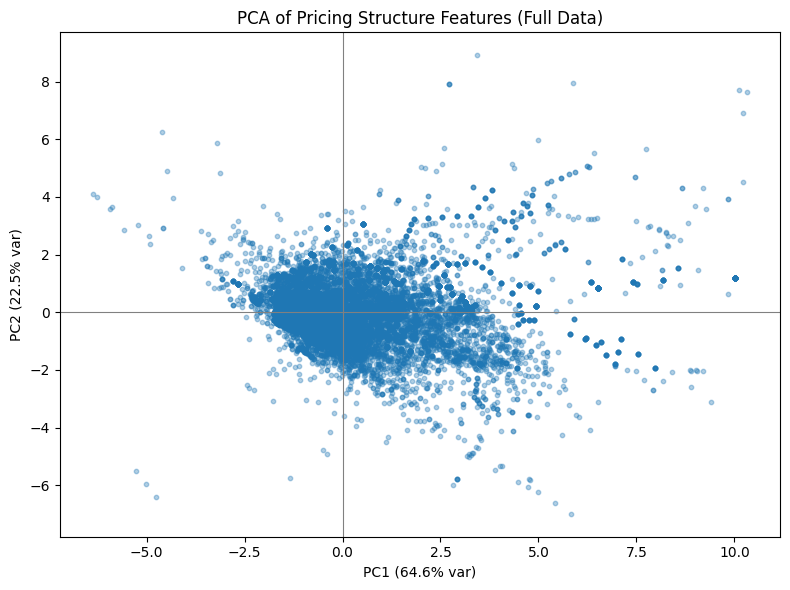

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.35, s=10)
plt.axhline(0, lw=0.8, c="gray")
plt.axvline(0, lw=0.8, c="gray")
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
plt.title("PCA of Pricing Structure Features (Full Data)")
plt.tight_layout()
plt.show()

The PCA scatter plot shows that most counties are concentrated along a single dominant direction, which is PC1, explaining about 64.6% of the variation. The shape looks more like a stretched cloud than clearly separated groups, suggesting that counties vary mostly along a continuous pricing structure gradient rather than forming distinct clusters. PC2 adds some variation, but it does not create strong visual separation. Overall, this supports the idea that childcare pricing differences are largely driven by one main structural dimension.

In [ ]:
dist_pc = np.sqrt(X_pca[:,0]**2 + X_pca[:,1]**2)
thr_95 = np.percentile(dist_pc, 95)
thr_99 = np.percentile(dist_pc, 99)

df_model["extreme_top5pct"] = dist_pc >= thr_95
df_model["extreme_top1pct"] = dist_pc >= thr_99

print("Top 5% extreme count:", df_model["extreme_top5pct"].sum())
print("Top 1% extreme count:", df_model["extreme_top1pct"].sum())

Top 5% extreme count: 1172
Top 1% extreme count: 234


I determined each county's distance from the distribution center using the PCA coordinates, and  marked the top 5% and top 1% as extreme. A tiny fraction of the counties is located distant from the main cluster, with 1,172 counties in the top 5% and 234 in the top 1%. A large portion of the gap shown in previous clustering results is probably being driven by these counties. This begs the question of whether they are the extreme of a continuous affordability continuum or a truly distinct price regime.

# **5. UMAP: Testing for Non-Linear Structure**

In [ ]:
umap_model = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2, metric="euclidean", random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


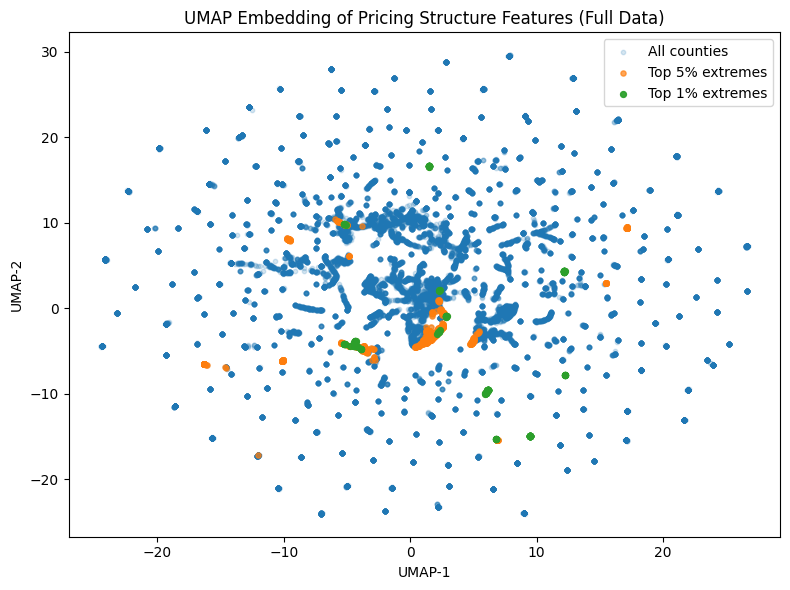

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], alpha=0.18, s=10, label="All counties")

mask5 = df_model["extreme_top5pct"].values
mask1 = df_model["extreme_top1pct"].values

plt.scatter(X_umap[mask5,0], X_umap[mask5,1], alpha=0.7, s=14, label="Top 5% extremes")
plt.scatter(X_umap[mask1,0], X_umap[mask1,1], alpha=0.95, s=18, label="Top 1% extremes")

plt.title("UMAP Embedding of Pricing Structure Features (Full Data)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.tight_layout()
plt.show()

The UMAP embedding maintains local links between counties while displaying the pricing structure features in a non-linear space. UMAP disperses counties into a more rounded shape than PCA, which focused on a single dominant gradient. Instead of creating a tight, distinct group, the extreme counties (top 5% and top 1%), however, continue to appear primarily on the periphery. This implies that the daycare market may still represent a continuous spectrum rather than distinctly different structural regimes even when employing a non-linear approach.

# **6. Clustering in UMAP Space**

While PCA suggested that most variation in pricing structure features lies along a dominant linear gradient, this does not rule out the possibility of hidden non-linear structure. To further investigate whether childcare markets form distinct regimes rather than a continuous affordability spectrum, we apply UMAP to the full standardized dataset, including extreme counties. Unlike PCA, UMAP preserves local neighborhood relationships and may reveal clusters that are not visible in linear projections.


In [ ]:
ks = range(2, 11)
rows = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = km.fit_predict(X_umap)

    sil = silhouette_score(X_umap, labels)
    sizes = pd.Series(labels).value_counts()
    balance = sizes.min() / sizes.max()

    rows.append({
        "k": k,
        "silhouette_umap": round(sil, 4),
        "min_cluster": int(sizes.min()),
        "max_cluster": int(sizes.max()),
        "balance_ratio": round(balance, 3)
    })

umap_k_df = pd.DataFrame(rows)
display(umap_k_df)

,k,silhouette_umap,min_cluster,max_cluster,balance_ratio
0,2,0.3038,11477,11865,0.967
1,3,0.3201,5552,9205,0.603
2,4,0.3286,3734,7860,0.475
3,5,0.3448,2522,7504,0.336
4,6,0.3593,2355,7411,0.318
5,7,0.3585,1883,7426,0.254
6,8,0.3566,1650,5834,0.283
7,9,0.3477,1417,5319,0.266
8,10,0.3561,1179,4722,0.250


Based on the output above, I am choosing to go ahead with a k value of 6 since it has the maximum value in the silhouette umap before it tapers out as the value of k increases.

In [ ]:
k_umap = 6

kmeans_umap = KMeans(n_clusters=k_umap, random_state=42, n_init=25)
df_model["umap_cluster"] = kmeans_umap.fit_predict(X_umap)

print("Cluster sizes (UMAP space):")
print(df_model["umap_cluster"].value_counts().sort_index())

Cluster sizes (UMAP space):
umap_cluster
0    3256
1    2527
2    2355
3    2994
4    7411
5    4799
Name: count, dtype: int64


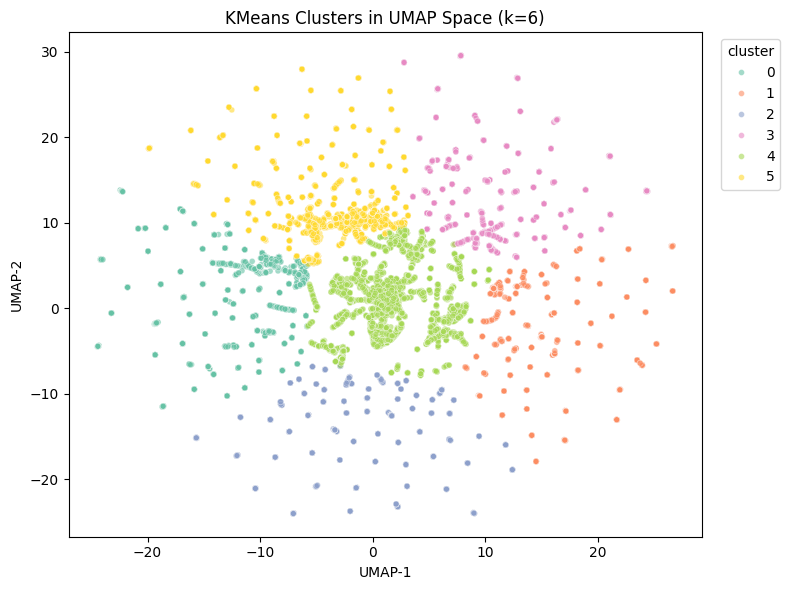

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_umap[:,0],
    y=X_umap[:,1],
    hue=df_model["umap_cluster"],
    palette="Set2",
    alpha=0.6,
    s=18
)
plt.title(f"KMeans Clusters in UMAP Space (k={k_umap})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

By projecting counties into a two-dimensional space according to their standardized childcare pricing structure features, the UMAP embedding enables the emergence of non-linear interactions. Six clusters that seem more radially scattered than linearly separated are found by KMeans with k = 6, indicating regional groupings as opposed to a single prevailing affordability gradient. Even while the clusters exhibit clear structure, particularly around the periphery, the middle area is still very dense and continuous, suggesting that many counties continue to fall within a common price range. This pattern lends credence to the notion that, despite the existence of certain regimes, the childcare market structure primarily exhibits progressive change as opposed to clearly defined divisions.

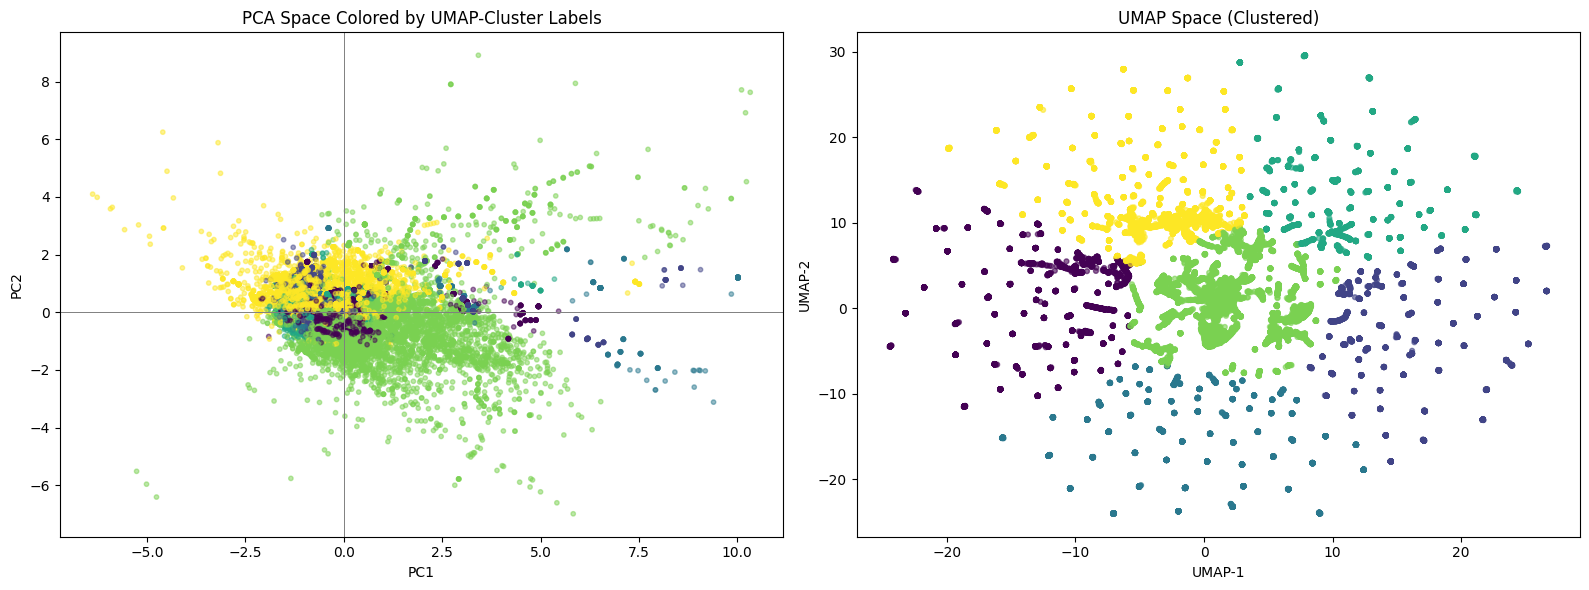

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA view colored by UMAP clusters
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=df_model["umap_cluster"], alpha=0.5, s=10)
axes[0].axhline(0, lw=0.7, c="gray")
axes[0].axvline(0, lw=0.7, c="gray")
axes[0].set_title("PCA Space Colored by UMAP-Cluster Labels")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# UMAP view
axes[1].scatter(X_umap[:,0], X_umap[:,1], c=df_model["umap_cluster"], alpha=0.6, s=12)
axes[1].set_title("UMAP Space (Clustered)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

The identical UMAP-based cluster labels are displayed in PCA space and UMAP space in this side-by-side comparison. The clusters appear to be highly overlapped and primarily grouped along a single dominant gradient in the PCA plot (left), supporting the notion that PCA is capturing a basically continuous affordability spectrum. The UMAP plot (right), on the other hand, shows a more distinct local distinction between groups, indicating the possibility of non-linear structure in the data. Even in UMAP space, though, the clusters are connected by a dense center and are relatively radial, suggesting that even while different price regimes appear, the childcare market still functions mostly as a smooth continuum rather than as sharply split portions.

# **7. Including Outliers**

This seciton will include the outliers to figure out whether they are a driving force behind the data.

In [ ]:
extreme5 = df_model["extreme_top5pct"]
extreme1 = df_model["extreme_top1pct"]

extreme_summary = (
    df_model.groupby("umap_cluster")
    .agg(
        n=("county_fips_code", "count"),
        pct_extreme5=("extreme_top5pct", "mean"),
        pct_extreme1=("extreme_top1pct", "mean")
    )
    .reset_index()
)

extreme_summary["pct_extreme5"] = (extreme_summary["pct_extreme5"] * 100).round(1)
extreme_summary["pct_extreme1"] = (extreme_summary["pct_extreme1"] * 100).round(1)

display(extreme_summary.sort_values("pct_extreme5", ascending=False))

,umap_cluster,n,pct_extreme5,pct_extreme1
4,4,7411,9.4,1.0
2,2,2355,7.0,4.4
1,1,2527,2.8,1.1
0,0,3256,2.7,0.0
5,5,4799,2.4,0.5
3,3,2994,1.2,0.0


The distribution of the most extreme counties among the UMAP clusters is displayed in this table. In addition to having 1% of the most extreme counties, Cluster 4 has the highest percentage of top 5% extremes (9.4%), indicating that some high-cost outliers do concentrate in this group. However, as other clusters also include significant shares of top 5% and top 1% observations, extreme counties are not separated into a single cluster. This suggests that although extreme price structures are somewhat separated by UMAP, the extremes nevertheless seem to be partially entrenched within the larger continuum rather than constituting an entirely separate economic regime.

# **8. Cluster Interpretation and Structure Validation**

In [ ]:
cluster_profile = (df_model.groupby("umap_cluster")[cluster_features + socio_vars].mean().round(2))

display(cluster_profile)

,infant_preschool_gradient_center,toddler_preschool_gradient_center,provider_gap_infant_center_minus_family,provider_gap_preschool_center_minus_family,mhi_2018,pr_p,flfpr_20to64
umap_cluster,,,,,,,
0,25.75,6.96,32.89,16.30,51523.63,15.39,69.59
1,21.61,8.58,27.25,12.54,47339.59,17.49,67.14
2,20.80,8.89,29.30,16.78,48196.12,17.41,68.55
3,13.48,6.01,16.99,11.18,45471.17,17.68,68.31
4,28.01,8.11,47.73,30.16,54341.99,14.86,71.52
5,24.88,9.84,21.78,7.00,49456.45,16.26,69.04


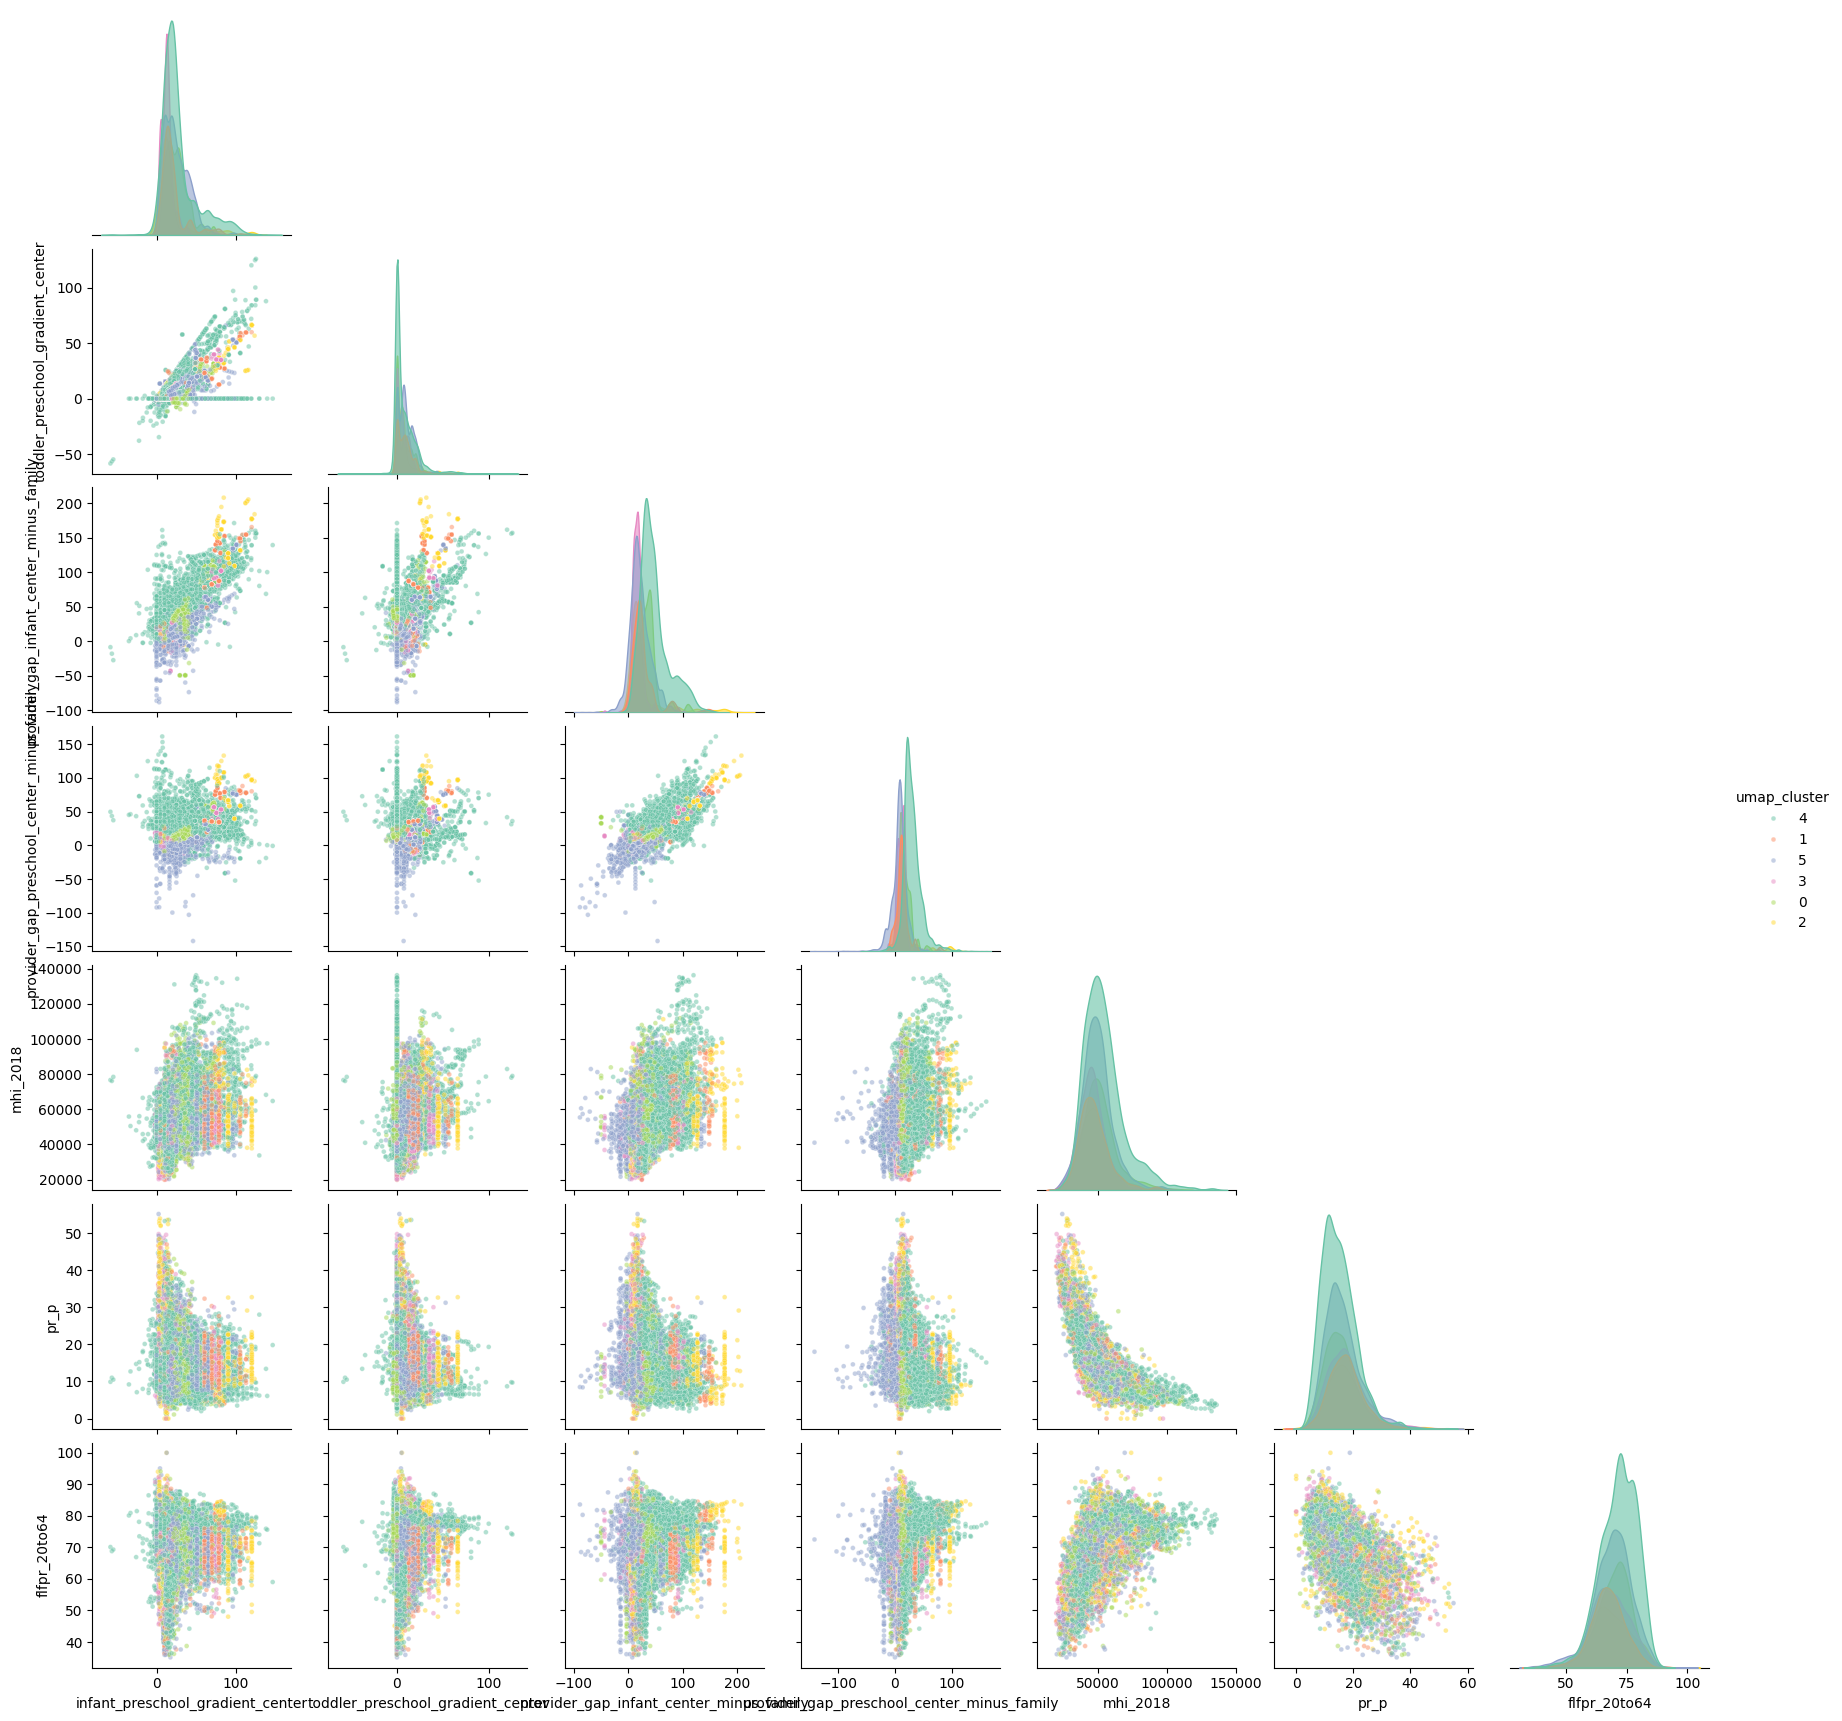

In [ ]:
pairplot_vars = cluster_features + socio_vars + ["umap_cluster"]
plot_df = df_model[pairplot_vars].copy()
plot_df["umap_cluster"] = plot_df["umap_cluster"].astype(str)

sns.pairplot(
    plot_df,
    hue="umap_cluster",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={"alpha": 0.5, "s": 12},
    diag_kws={"alpha": 0.6}
)
plt.show()

The UMAP-based clusters' differences across pricing structure aspects and important socioeconomic indicators are displayed in this pairplot. The fact that there is still a substantial correlation between the gradients and provider gaps supports the notion that a common affordability feature accounts for a large portion of the variation. While some clusters focus on lower-cost and lower-income groups, others show considerably larger pricing discrepancies and steeper age-based gradients. Although the market functions primarily as a continuum, there are pockets of counties that share unique structural pricing and socioeconomic profiles rather than forming a single, homogeneous group, as evidenced by the shifting distributions of income, poverty, and female labor force participation across clusters.